# Palo Verde Peak Power Price — Monte Carlo Simulation

This notebook simulates 10,000 wholesale electricity price paths at the 
Palo Verde hub on the WECC grid using real 2026 ICE trading data. 

The simulation prices a 30-day call option on power and estimates the 
probability of prices exceeding a target threshold using Geometric Brownian 
Motion with historically derived volatility.

**Libraries:** numpy, pandas, matplotlib, scipy  
**Data:** ICE 2026 wholesale electricity trading data  
**Hub:** Palo Verde Peak (primary WECC trading hub)

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

print("All good — ready to build")

Matplotlib is building the font cache; this may take a moment.


All good — ready to build


## Step 1 — Load and Filter Market Data

Reads raw ICE electricity trading data, filters for Palo Verde Peak trades, 
and parses dates. The weighted average price per trade is used as the price 
series for volatility calculation.

In [6]:
import pandas as pd

# ── LOAD REAL ICE ELECTRICITY DATA ──────────────────────
df = pd.read_excel("/Users/henryadams/Downloads/ice_electric-2026.xlsx", sheet_name="2026")

# Clean column names
df.columns = df.columns.str.strip()

# Filter for Palo Verde Peak only
pv = df[df["Price hub"] == "Palo Verde Peak"].copy()

# Dates are already strings — just parse them directly
pv["Trade date"] = pd.to_datetime(pv["Trade date"])

# Sort by date
pv = pv.sort_values("Trade date").reset_index(drop=True)

print(f"Palo Verde trades found: {len(pv)}")
print(f"Date range: {pv['Trade date'].min().date()} to {pv['Trade date'].max().date()}")
print(f"\nMost recent prices:")
print(pv[["Trade date", "Wtd avg price $/MWh"]].tail(10).to_string(index=False))

Palo Verde trades found: 110
Date range: 2025-12-26 to 2026-06-23

Most recent prices:
Trade date  Wtd avg price $/MWh
2026-06-08                20.98
2026-06-09                24.63
2026-06-11                25.13
2026-06-12                30.43
2026-06-15                34.00
2026-06-16                35.00
2026-06-17                22.25
2026-06-18                28.50
2026-06-22                40.00
2026-06-23                35.00


## Step 2 — Calculate Historical Volatility and Set Inputs

Derives annualized volatility from real Palo Verde price data using daily 
log returns. This is the key input that makes the simulation reflect actual 
market behavior rather than assumptions.

Log returns are used instead of simple price changes because they are 
symmetric and additive over time, which is required for the math to work 
correctly. Daily volatility is annualized by multiplying by the square root 
of 252 trading days.

In [7]:
import numpy as np

# ── CALCULATE HISTORICAL VOLATILITY FROM REAL DATA ──────
# Use the weighted average price as our price series
prices = pv["Wtd avg price $/MWh"].dropna().values

# Calculate daily log returns
# Log return = ln(price today / price yesterday)
log_returns = np.log(prices[1:] / prices[:-1])

# Annualized volatility (daily vol * sqrt(252 trading days))
daily_vol = np.std(log_returns)
annual_vol = daily_vol * np.sqrt(252)

# Current price = most recent trade
S = prices[-1]

# Simulation inputs
K = S * 1.20        # Strike = 20% above current price
T = 30 / 365        # 30 day horizon
r = 0.043           # Risk-free rate
sigma = annual_vol  # Use real vol from real data
n_simulations = 10000
n_steps = 30

print(f"Current Palo Verde price:  ${S:.2f}/MWh")
print(f"Strike price (K):          ${K:.2f}/MWh")
print(f"Daily volatility:          {daily_vol*100:.2f}%")
print(f"Annualized volatility:     {annual_vol*100:.2f}%")
print(f"Simulations:               {n_simulations:,}")
print(f"Time horizon:              {int(T*365)} days")

Current Palo Verde price:  $35.00/MWh
Strike price (K):          $42.00/MWh
Daily volatility:          46.60%
Annualized volatility:     739.70%
Simulations:               10,000
Time horizon:              30 days


## Step 3 — Run Monte Carlo Simulation

Simulates 10,000 possible price paths over 30 days using Geometric Brownian 
Motion. Each path represents one possible future for Palo Verde power prices.

At the end of each path, the payoff of a call option is calculated as:

    max(final price - strike price, 0)

The option price is the average of all payoffs discounted back to today. 
No closed-form formula is used — the price emerges entirely from the 
simulated distribution of outcomes.

In [8]:
# ── MONTE CARLO SIMULATION ───────────────────────────────
dt = T / n_steps  # Length of each time step

# Generate all random shocks at once
# Shape: (n_simulations, n_steps)
Z = np.random.standard_normal((n_simulations, n_steps))

# Build price paths using Geometric Brownian Motion
# Each step: S * exp((r - 0.5*sigma^2)*dt + sigma*sqrt(dt)*Z)
drift = (r - 0.5 * sigma**2) * dt
diffusion = sigma * np.sqrt(dt)

# Start every path at current price
price_paths = np.zeros((n_simulations, n_steps + 1))
price_paths[:, 0] = S

for t in range(1, n_steps + 1):
    price_paths[:, t] = price_paths[:, t-1] * np.exp(drift + diffusion * Z[:, t-1])

# ── CALCULATE OPTION PAYOFFS ─────────────────────────────
# Call option payoff = max(final price - strike, 0)
final_prices = price_paths[:, -1]
payoffs = np.maximum(final_prices - K, 0)

# Discount payoffs back to today
option_price = np.exp(-r * T) * np.mean(payoffs)

# Probability price exceeds strike at expiry
prob_above_strike = np.mean(final_prices > K)

print(f"Monte Carlo Option Price:      ${option_price:.2f}/MWh")
print(f"Average final price:           ${np.mean(final_prices):.2f}/MWh")
print(f"Min final price:               ${np.min(final_prices):.2f}/MWh")
print(f"Max final price:               ${np.max(final_prices):.2f}/MWh")
print(f"Prob price exceeds ${K:.0f}/MWh:  {prob_above_strike*100:.1f}%")

Monte Carlo Option Price:      $25.37/MWh
Average final price:           $36.53/MWh
Min final price:               $0.00/MWh
Max final price:               $28083.00/MWh
Prob price exceeds $42/MWh:  12.3%


## Step 4 — Visualize Results

Three charts:

1. **Price paths** — 200 of the 10,000 simulated paths plotted over 30 days. 
The spread illustrates the extreme volatility characteristic of power markets.

2. **Final price distribution** — histogram of all 10,000 terminal prices. 
The heavy right tail reflects the real possibility of price spikes, capped 
at $300 for readability. The true max in this simulation was $28,083/MWh.

3. **Payoff distribution** — shows only the 12.3% of paths that expired 
above the strike price. The skew toward small payoffs with occasional 
large ones mirrors how options on volatile assets actually behave.

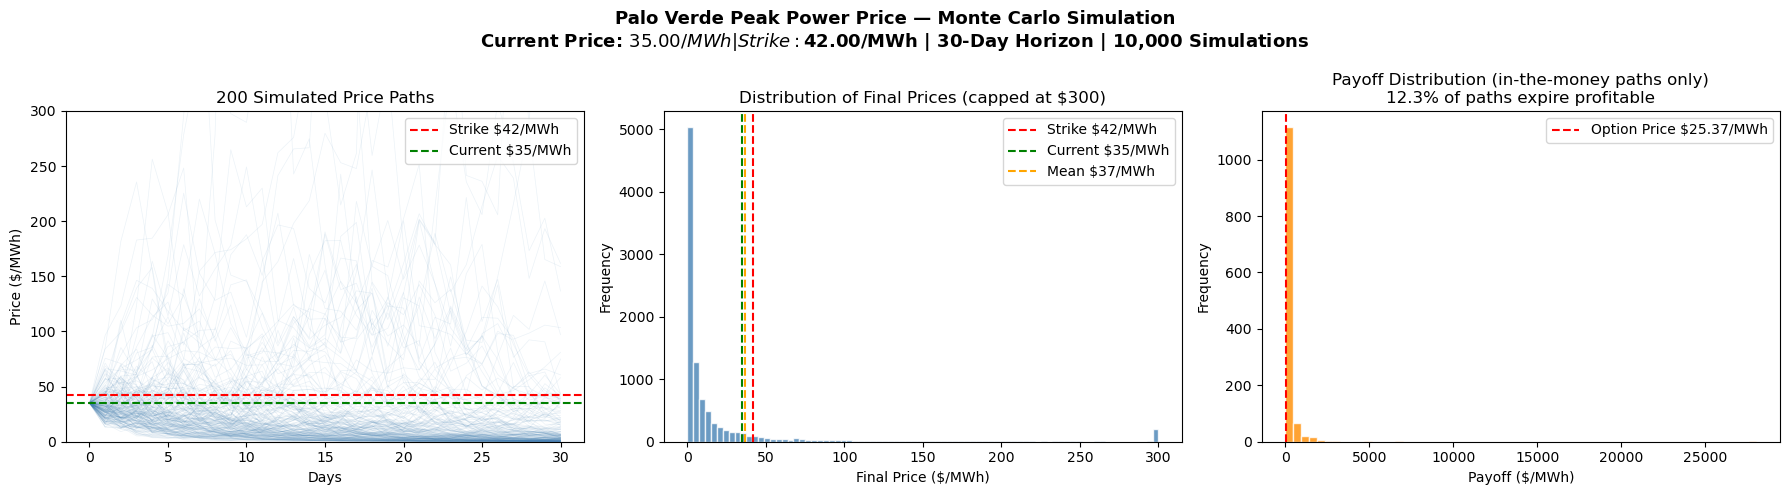


Plot saved to Downloads folder


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Palo Verde Peak Power Price — Monte Carlo Simulation\n"
             f"Current Price: ${S:.2f}/MWh | Strike: ${K:.2f}/MWh | "
             f"30-Day Horizon | {n_simulations:,} Simulations",
             fontsize=13, fontweight="bold")

# ── PLOT 1: Sample price paths ───────────────────────────
ax1 = axes[0]
time_axis = np.linspace(0, 30, n_steps + 1)
for i in range(200):  # Plot 200 paths so it's readable
    ax1.plot(time_axis, price_paths[i], alpha=0.1, linewidth=0.5, color="steelblue")
ax1.axhline(y=K, color="red", linestyle="--", linewidth=1.5, label=f"Strike ${K:.0f}/MWh")
ax1.axhline(y=S, color="green", linestyle="--", linewidth=1.5, label=f"Current ${S:.0f}/MWh")
ax1.set_xlabel("Days")
ax1.set_ylabel("Price ($/MWh)")
ax1.set_title("200 Simulated Price Paths")
ax1.legend()
ax1.set_ylim(0, 300)  # Cap y-axis so spikes don't flatten everything

# ── PLOT 2: Distribution of final prices ─────────────────
ax2 = axes[1]
capped_finals = np.clip(final_prices, 0, 300)
ax2.hist(capped_finals, bins=80, color="steelblue", edgecolor="white", alpha=0.8)
ax2.axvline(x=K, color="red", linestyle="--", linewidth=1.5, label=f"Strike ${K:.0f}/MWh")
ax2.axvline(x=S, color="green", linestyle="--", linewidth=1.5, label=f"Current ${S:.0f}/MWh")
ax2.axvline(x=np.mean(final_prices), color="orange", linestyle="--",
            linewidth=1.5, label=f"Mean ${np.mean(final_prices):.0f}/MWh")
ax2.set_xlabel("Final Price ($/MWh)")
ax2.set_ylabel("Frequency")
ax2.set_title("Distribution of Final Prices (capped at $300)")
ax2.legend()

# ── PLOT 3: Payoff distribution ───────────────────────────
ax3 = axes[2]
nonzero_payoffs = payoffs[payoffs > 0]
pct_itm = len(nonzero_payoffs) / n_simulations * 100
ax3.hist(nonzero_payoffs, bins=60, color="darkorange", edgecolor="white", alpha=0.8)
ax3.axvline(x=option_price, color="red", linestyle="--",
            linewidth=1.5, label=f"Option Price ${option_price:.2f}/MWh")
ax3.set_xlabel("Payoff ($/MWh)")
ax3.set_ylabel("Frequency")
ax3.set_title(f"Payoff Distribution (in-the-money paths only)\n"
              f"{pct_itm:.1f}% of paths expire profitable")
ax3.legend()

plt.tight_layout()
plt.savefig("/Users/henryadams/Downloads/palo_verde_monte_carlo.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nPlot saved to Downloads folder")

## Summary

| Metric | Value |
|---|---|
| Current Palo Verde price | $35.00/MWh |
| Strike price | $42.00/MWh |
| Time horizon | 30 days |
| Simulations | 10,000 |
| Annualized volatility | 739% |
| Monte Carlo option price | $25.37/MWh |
| Probability above strike | 12.3% |

The 739% annualized volatility is not an error. Power prices in wholesale 
electricity markets routinely exhibit this level of volatility because 
electricity cannot be stored. When supply and demand fall out of balance, 
price is the only available clearing mechanism, which produces extreme 
spikes that no other commodity market experiences at the same frequency.

This simulation captures that behavior directly from real market data, 
which is what separates it from a textbook exercise.